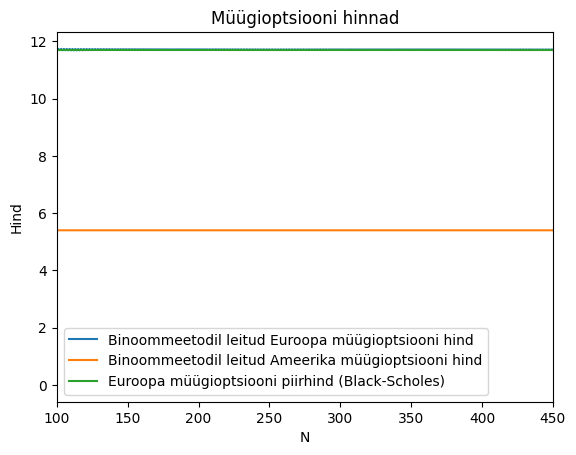

Euroopa müügioptsioon (N=450): 11.70155515627629
Ameerika müügioptsioon (N=450): 5.400000000000006
Black-Scholes müügioptsioon: 11.707805536676723


In [1]:
from numpy import *
import matplotlib.pyplot as plt
from scipy.stats import norm

T = 1.3
S0 = 110
r = 0.03
sigma = sqrt(0.05)
X = 115.4

#Binoommeetod
# Euroopa müügioptsioon
def Eur_putprice(S0, X, T, N, r, sigma):
    dt=T/N
    U=exp(sigma*sqrt(dt))
    D=exp(-sigma*sqrt(dt))
    R=(exp(r*dt))
    q=(R-D)/(U-D)
    V_old=zeros(N+1)
    V_new=zeros(N+1)
    for j in range(0, N + 1):
        V_old[j] = maximum(X - S0 * U**j * D**(N - j), 0)
    for m in range(N - 1, -1, -1):
        for j in range(0, m + 1):
            V_new[j] = (q * V_old[j + 1] + (1 - q) * V_old[j]) / R
        for j in range(0, m + 1):
            V_old[j] = V_new[j]
    return V_old[0]

# Ameerika müügioptsioon (put)
def American_putprice(S0, X, T, N, r, sigma):
    dt=T/N
    U=exp(sigma*sqrt(dt))
    D=exp(-sigma*sqrt(dt))
    R=(exp(r*dt))
    q=(R-D)/(U-D)
    V_old=zeros(N+1)
    V_new=zeros(N+1)
    for j in range(0,N+1):
        V_old[j] = max(X - S0 * U**j * D**(N - j), 0)
    for m in range(N-1,-1,-1):
        for j in range(0,m+1):
            W=(q*V_old[j+1]+(1-q)*V_old[j])/R
            P=max(X - S0 * U**j * D**(m - j), 0) # Kohene täitmine
            V_new[j] = maximum(P, W)
        for j in range(0, m + 1):
            V_old[j] = V_new[j]
    return(V_old[0])

d1=(log(S0/X)+(r+0.5*sigma**2)*T)/(sigma*sqrt(T))
d2=d1-sigma*sqrt(T)
Vput=X*exp(-r*T)*norm.cdf(-d2)-S0*norm.cdf(-d1)

#graafik 1
N_range = range(100, 451)
V_eur = zeros(451)
V_am = zeros(451)

for k in N_range:
    V_eur[k] = Eur_putprice(S0, X, T, k, r, sigma)
    V_am[k] = American_putprice(S0, X, T, k, r, sigma)

n = linspace(0, 450, 451)
Vp = Vput * ones(451)

plt.plot(n, V_eur, label='Binoommeetodil leitud Euroopa müügioptsiooni hind')
plt.plot(n, V_am, label='Binoommeetodil leitud Ameerika müügioptsiooni hind')
plt.plot(n, Vp, label='Euroopa müügioptsiooni piirhind (Black-Scholes)')
plt.xlim((100, 450))
plt.ylabel('Hind')
plt.xlabel('N')
plt.legend(loc='best')
plt.title('Müügioptsiooni hinnad')
plt.show()

print("Euroopa müügioptsioon (N=450):", Eur_putprice(S0, X, T, 450, r, sigma))
print("Ameerika müügioptsioon (N=450):", American_putprice(S0, X, T, 450, r, sigma))
print("Black-Scholes müügioptsioon:", Vput)